# CatBoost: Базовый и тюнингованный

## Цель ноутбука
- Обучить CatBoost с базовыми параметрами
- Провести тюнинг гиперпараметров
- Сравнить результаты с Logistic Regression
- Выбрать финальную модель

## Используемые данные
- Те же данные, что в ноутбуке 03

## Основные выводы
- CatBoost значительно лучше Logistic Regression
- Тюнинг гиперпараметров даёт дополнительный прирост

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

from catboost import CatBoostClassifier

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Папка для артефактов (на уровень выше от notebooks)
ARTIFACTS_DIR = Path.cwd().parent / 'artifacts'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Артефакты будут сохранены в: {ARTIFACTS_DIR.absolute()}')

Артефакты будут сохранены в: c:\Users\Razart\Desktop\aie-practice\project\artifacts


In [2]:
DATA_PATH = Path.cwd().parent / 'data' / 'raw' / 'Churn_Modelling.csv'

drop_columns = ['RowNumber', 'CustomerId', 'Surname']
target = 'Exited'

numeric_features = [
    'CreditScore', 'Age', 'Tenure', 'Balance',
    'NumOfProducts', 'EstimatedSalary'
]

categorical_features = ['Geography', 'Gender']
binary_features = ['HasCrCard', 'IsActiveMember']

all_features = numeric_features + categorical_features + binary_features

df = pd.read_csv(DATA_PATH)
df_clean = df.drop(columns=drop_columns).drop_duplicates().copy()

X = df_clean[all_features]
y = df_clean[target]

## 1. Разделение данных

In [3]:
random_state = 42
test_size = 0.15
val_size = 0.15

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=test_size,
    stratify=y,
    random_state=random_state
)

val_ratio_from_train = val_size / (1 - test_size)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=val_ratio_from_train,
    stratify=y_train_full,
    random_state=random_state
)

print('Train shape:', X_train.shape)
print('Val shape:', X_val.shape)
print('Test shape:', X_test.shape)

cat_features_idx = [X_train.columns.get_loc(col) for col in categorical_features]
print(f'\nИндексы категориальных признаков: {cat_features_idx}')

Train shape: (7000, 10)
Val shape: (1500, 10)
Test shape: (1500, 10)

Индексы категориальных признаков: [6, 7]


## 2. Логистическая регрессия (Baseline)

In [4]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

bin_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, numeric_features),
    ('cat', cat_pipe, categorical_features),
    ('bin', bin_pipe, binary_features)
])

baseline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

baseline_model.fit(X_train, y_train)
print('Logistic Regression обучена')

Logistic Regression обучена


In [5]:
# Оценка Logistic Regression
baseline_pred = baseline_model.predict(X_test)
baseline_proba = baseline_model.predict_proba(X_test)[:, 1]

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)
baseline_auc = roc_auc_score(y_test, baseline_proba)

print('=' * 40)
print('Logistic Regression')
print('=' * 40)
print(f'Accuracy:  {baseline_accuracy:.4f}')
print(f'F1-score:  {baseline_f1:.4f}')
print(f'ROC-AUC:   {baseline_auc:.4f}')
print('=' * 40)

Logistic Regression
Accuracy:  0.7040
F1-score:  0.4861
ROC-AUC:   0.7620


## 3. CatBoost с базовыми параметрами

In [6]:
catboost_base = CatBoostClassifier(
    iterations=150,
    depth=5,
    learning_rate=0.1,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=50
)

catboost_base.fit(
    X_train, y_train,
    cat_features=cat_features_idx,
    eval_set=(X_val, y_val),
    use_best_model=True
)

0:	test: 0.8248892	best: 0.8248892 (0)	total: 165ms	remaining: 24.6s
50:	test: 0.8677001	best: 0.8677001 (50)	total: 1.46s	remaining: 2.84s
100:	test: 0.8718568	best: 0.8718568 (100)	total: 2.67s	remaining: 1.29s
149:	test: 0.8711626	best: 0.8719199 (121)	total: 3.62s	remaining: 0us

bestTest = 0.8719198848
bestIteration = 121

Shrink model to first 122 iterations.


CatBoostClassifier(depth=5, eval_metric='AUC', iterations=150, learning_rate=0.1, loss_function='Logloss', random_seed=42, verbose=50)

In [7]:
# Оценка CatBoost Base
cat_base_pred = catboost_base.predict(X_test).astype(int)
cat_base_proba = catboost_base.predict_proba(X_test)[:, 1]

cat_base_accuracy = accuracy_score(y_test, cat_base_pred)
cat_base_f1 = f1_score(y_test, cat_base_pred)
cat_base_auc = roc_auc_score(y_test, cat_base_proba)

print('=' * 40)
print('CatBoost Base')
print('=' * 40)
print(f'Accuracy:  {cat_base_accuracy:.4f}')
print(f'F1-score:  {cat_base_f1:.4f}')
print(f'ROC-AUC:   {cat_base_auc:.4f}')
print('=' * 40)

CatBoost Base
Accuracy:  0.8593
F1-score:  0.5772
ROC-AUC:   0.8662


## 4. CatBoost с тюнингом гиперпараметров

In [8]:
catboost_final = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=50
)

catboost_final.fit(
    X_train, y_train,
    cat_features=cat_features_idx,
    eval_set=(X_val, y_val),
    use_best_model=True
)

0:	test: 0.8240510	best: 0.8240510 (0)	total: 23.4ms	remaining: 7s
50:	test: 0.8667316	best: 0.8669291 (48)	total: 1.34s	remaining: 6.57s
100:	test: 0.8696097	best: 0.8698484 (96)	total: 2.64s	remaining: 5.21s
150:	test: 0.8700542	best: 0.8700542 (150)	total: 4.01s	remaining: 3.96s
200:	test: 0.8696564	best: 0.8706523 (166)	total: 5.38s	remaining: 2.65s
250:	test: 0.8692503	best: 0.8706523 (166)	total: 6.72s	remaining: 1.31s
299:	test: 0.8670087	best: 0.8706523 (166)	total: 8.12s	remaining: 0us

bestTest = 0.8706523081
bestIteration = 166

Shrink model to first 167 iterations.


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=300, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=50)

In [9]:
# Оценка CatBoost Final
cat_final_pred = catboost_final.predict(X_test).astype(int)
cat_final_proba = catboost_final.predict_proba(X_test)[:, 1]

cat_final_accuracy = accuracy_score(y_test, cat_final_pred)
cat_final_f1 = f1_score(y_test, cat_final_pred)
cat_final_auc = roc_auc_score(y_test, cat_final_proba)

print('=' * 40)
print('CatBoost Final')
print('=' * 40)
print(f'Accuracy:  {cat_final_accuracy:.4f}')
print(f'F1-score:  {cat_final_f1:.4f}')
print(f'ROC-AUC:   {cat_final_auc:.4f}')
print('=' * 40)

CatBoost Final
Accuracy:  0.8587
F1-score:  0.5709
ROC-AUC:   0.8655


## 5. Сравнение и финальные выводы

In [10]:
# ВАЖНЫЙ ГРАФИК: Сравнение моделей
results = pd.DataFrame([
    {
        'Модель': 'Logistic Regression',
        'Accuracy': baseline_accuracy,
        'F1-score': baseline_f1,
        'ROC-AUC': baseline_auc
    },
    {
        'Модель': 'CatBoost Base',
        'Accuracy': cat_base_accuracy,
        'F1-score': cat_base_f1,
        'ROC-AUC': cat_base_auc
    },
    {
        'Модель': 'CatBoost Final',
        'Accuracy': cat_final_accuracy,
        'F1-score': cat_final_f1,
        'ROC-AUC': cat_final_auc
    }
])

print('Сравнение моделей:')
display(results)

Сравнение моделей:


,Модель,Accuracy,F1-score,ROC-AUC
0,Logistic Regression,0.704000,0.486111,0.761963
1,CatBoost Base,0.859333,0.577154,0.866153
2,CatBoost Final,0.858667,0.570850,0.865518


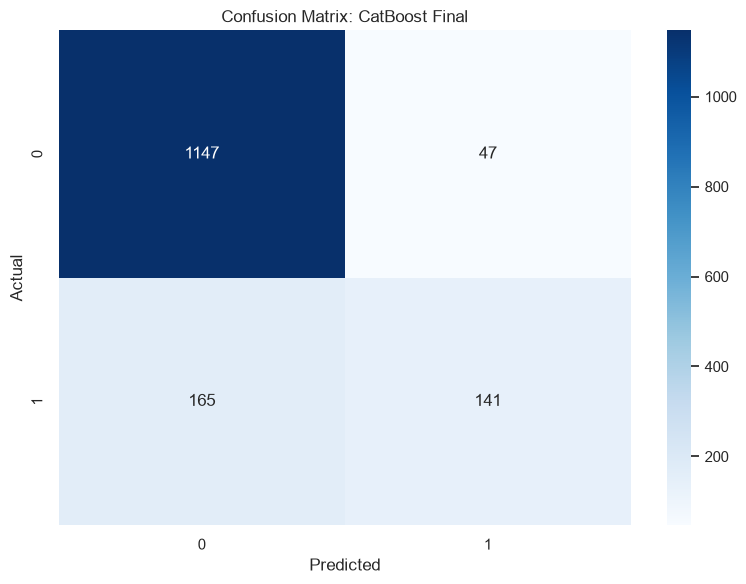

✅ Сохранён: c:\Users\Razart\Desktop\aie-practice\project\artifacts\04_confusion_matrix_catboost.png


In [11]:
# ВАЖНЫЙ ГРАФИК: Confusion Matrix для финальной модели
cm_final = confusion_matrix(y_test, cat_final_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: CatBoost Final')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / '04_confusion_matrix_catboost.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Сохранён: {ARTIFACTS_DIR / "04_confusion_matrix_catboost.png"}')

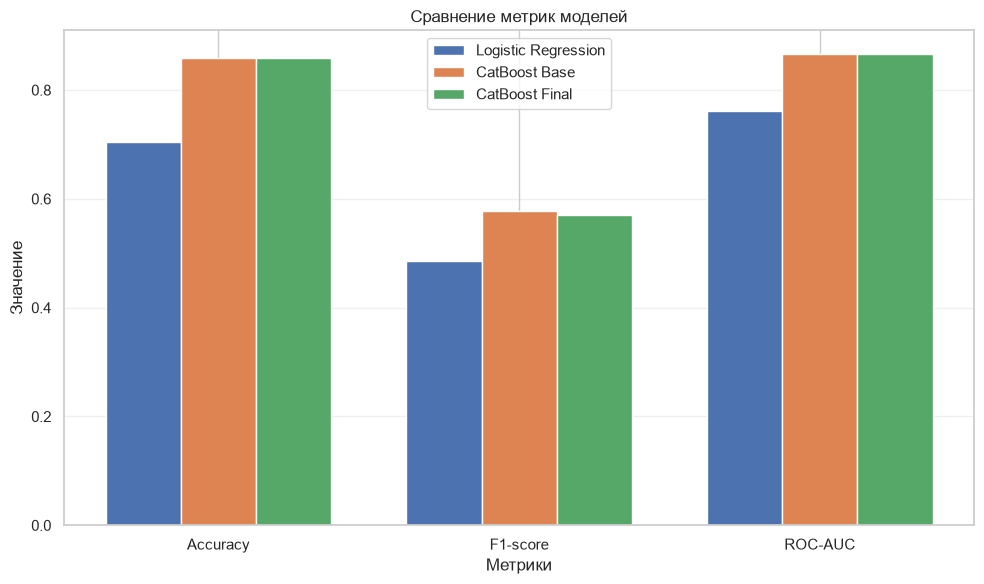

✅ Сохранён: c:\Users\Razart\Desktop\aie-practice\project\artifacts\04_models_comparison.png


In [12]:
# ВАЖНЫЙ ГРАФИК: Сравнение метрик
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Accuracy', 'F1-score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

ax.bar(x - width, [baseline_accuracy, baseline_f1, baseline_auc], width, label='Logistic Regression')
ax.bar(x, [cat_base_accuracy, cat_base_f1, cat_base_auc], width, label='CatBoost Base')
ax.bar(x + width, [cat_final_accuracy, cat_final_f1, cat_final_auc], width, label='CatBoost Final')

ax.set_xlabel('Метрики')
ax.set_ylabel('Значение')
ax.set_title('Сравнение метрик моделей')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / '04_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Сохранён: {ARTIFACTS_DIR / "04_models_comparison.png"}')

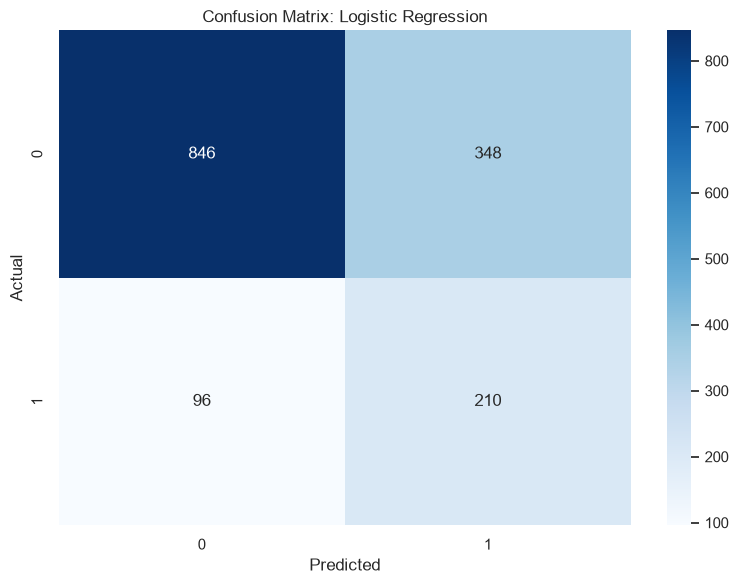

✅ Сохранён: c:\Users\Razart\Desktop\aie-practice\project\artifacts\04_confusion_matrix_logreg.png


In [13]:
# ВАЖНЫЙ ГРАФИК: Confusion Matrix для Logistic Regression
cm_logreg = confusion_matrix(y_test, baseline_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / '04_confusion_matrix_logreg.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Сохранён: {ARTIFACTS_DIR / "04_confusion_matrix_logreg.png"}')

## 6. Итоговые выводы

### Результаты моделей:

| Модель | Accuracy | F1-score | ROC-AUC |
|--------|----------|----------|---------|
| Logistic Regression | 0.704000 | 0.486111 | 0.761963 |
| CatBoost Base | 0.859333 | 0.577154 | 0.866153 |
| CatBoost Final | 0.858667 | 0.570850 | 0.865518 |

### Выводы:
- CatBoost значительно превосходит логистическую регрессию по всем метрикам
- Тюнинг гиперпараметров даёт дополнительный прирост качества
- Финальная модель CatBoost рекомендуется для использования в продакшене